The costs of establishing wind farms have risen by 35% due to technological upgrades and the specific demands of site selection. Investors in this sector incur massive expenses; without a precise analysis of historical data, they risk selecting suboptimal sites or inefficient turbines, thereby reducing financial returns

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df = pd.read_csv('wind-turbines.csv', encoding='latin1')

In [31]:
df

,case_id,faa_ors,faa_asn,usgs_pr_id,eia_id,t_state,t_county,t_fips,p_name,p_year,...,t_rsa,t_ttlh,retrofit,retrofit_year,t_conf_atr,t_conf_loc,t_img_date,t_img_srce,xlong,ylat
0,3072661,NaN,NaN,5149.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,NaN,NaN,0,NaN,2,3,5/8/2018,Digital Globe,-118.363762,35.077908
1,3072695,NaN,NaN,5143.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,NaN,NaN,0,NaN,2,3,5/8/2018,Digital Globe,-118.364410,35.077435
2,3072704,NaN,NaN,5146.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,NaN,NaN,0,NaN,2,3,5/8/2018,Digital Globe,-118.364197,35.077644
3,3063272,19-028134,2014-WTE-4084-OE,NaN,NaN,IA,Story County,19169,30 MW Iowa DG Portfolio,2017.0,...,12271.85,150.0,0,NaN,3,3,4/24/2017,Digital Globe,-93.430367,42.028233
4,3053390,19-028015,2015-WTE-6386-OE,NaN,NaN,IA,Boone County,19015,30 MW Iowa DG Portfolio,2017.0,...,12271.85,150.0,0,NaN,3,3,6/1/2017,Digital Globe,-93.700424,41.977608
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70803,3053232,36-120351,2015-WTE-5788-OE,NaN,NaN,NY,Wyoming County,36121,unknown Wyoming County,2016.0,...,NaN,NaN,0,NaN,1,3,5/20/2017,Digital Globe,-78.187935,42.740818
70804,3101958,48-171972,2020-WTW-2021-OE,NaN,NaN,TX,Young County,48503,unknown Young County,NaN,...,NaN,NaN,0,NaN,1,1,8/2/2020,Digital Globe,-98.907600,33.149414
70805,3040944,48-024978,2011-WTW-352-OE,41364.0,NaN,TX,Young County,48503,unknown Young County 1,2011.0,...,NaN,NaN,0,NaN,1,3,7/16/2018,Digital Globe,-98.551094,33.093292
70806,3055918,08-072237,2015-WTW-9995-OE,NaN,NaN,CO,Yuma County,8125,unknown Yuma County,2016.0,...,NaN,NaN,0,NaN,1,3,5/17/2017,Digital Globe,-102.716949,40.037548


In [32]:
df.describe()

,case_id,usgs_pr_id,eia_id,t_fips,p_year,p_tnum,p_cap,t_cap,t_hh,t_rd,t_rsa,t_ttlh,retrofit,retrofit_year,t_conf_atr,t_conf_loc,xlong,ylat
count,7.080800e+04,38263.000000,65015.000000,70808.000000,70195.000000,70808.000000,66326.000000,65328.000000,64628.000000,64874.000000,64874.000000,64628.000000,70808.000000,5986.000000,70808.000000,70808.000000,70808.000000,70808.000000
mean,3.058490e+06,27523.587225,57877.751642,32244.494097,2011.650659,104.360552,170.176128,1963.534151,81.054571,95.663717,7618.500657,129.050593,0.084538,2018.640327,2.766509,2.883784,-100.086457,38.479503
std,3.242377e+04,13564.446593,5984.516487,15498.246596,7.879099,93.954786,104.478693,717.067912,12.028726,23.424346,3309.229282,22.185981,0.278196,1.112294,0.597195,0.462326,11.141025,5.429730
min,3.000001e+06,1.000000,90.000000,2013.000000,1981.000000,1.000000,0.050000,50.000000,19.000000,13.400000,141.030000,30.400000,0.000000,2015.000000,1.000000,1.000000,-171.713074,13.389381
25%,3.032230e+06,18625.500000,56763.000000,19081.000000,2008.000000,56.000000,99.000000,1500.000000,80.000000,82.000000,5281.020000,121.000000,0.000000,2018.000000,3.000000,3.000000,-103.037155,34.428043
50%,3.050978e+06,28598.000000,57752.000000,35057.000000,2012.000000,85.000000,158.000000,2000.000000,80.000000,100.000000,7853.980000,130.100000,0.000000,2019.000000,3.000000,3.000000,-99.393761,39.052442
75%,3.090448e+06,38719.500000,60338.000000,48141.000000,2018.000000,121.000000,211.220000,2300.000000,87.000000,110.000000,9503.320000,145.100000,0.000000,2020.000000,3.000000,3.000000,-95.202499,42.812810
max,3.118671e+06,49135.000000,65270.000000,72133.000000,2021.000000,731.000000,525.020000,6000.000000,131.000000,155.000000,18869.190000,199.600000,1.000000,2020.000000,3.000000,3.000000,144.722656,66.839905


### 1.Identify the keys that affect the decision

In [33]:
df[['p_year', 't_cap', 't_hh', 't_rd']].describe()

,p_year,t_cap,t_hh,t_rd
count,70195.000000,65328.000000,64628.000000,64874.000000
mean,2011.650659,1963.534151,81.054571,95.663717
std,7.879099,717.067912,12.028726,23.424346
min,1981.000000,50.000000,19.000000,13.400000
25%,2008.000000,1500.000000,80.000000,82.000000
50%,2012.000000,2000.000000,80.000000,100.000000
75%,2018.000000,2300.000000,87.000000,110.000000
max,2021.000000,6000.000000,131.000000,155.000000


### 2.clean the dataset by removing pre-1990 turbines and invalid records

In [34]:
selected_cols = ['p_year', 't_state', 't_county', 't_manu', 't_cap', 't_hh', 't_rd']
df_clean = df[selected_cols].copy()
df_clean

,p_year,t_state,t_county,t_manu,t_cap,t_hh,t_rd
0,1987.0,CA,Kern County,Vestas,95.0,NaN,NaN
1,1987.0,CA,Kern County,Vestas,95.0,NaN,NaN
2,1987.0,CA,Kern County,Vestas,95.0,NaN,NaN
3,2017.0,IA,Story County,Nordex,3000.0,87.5,125.0
4,2017.0,IA,Boone County,Nordex,3000.0,87.5,125.0
...,...,...,...,...,...,...,...
70803,2016.0,NY,Wyoming County,NaN,NaN,NaN,NaN
70804,NaN,TX,Young County,NaN,NaN,NaN,NaN
70805,2011.0,TX,Young County,NaN,NaN,NaN,NaN
70806,2016.0,CO,Yuma County,NaN,NaN,NaN,NaN


In [35]:
df_clean = df_clean.dropna()
df_clean['p_year'] = df_clean['p_year'].astype(int)
df_clean

,p_year,t_state,t_county,t_manu,t_cap,t_hh,t_rd
3,2017,IA,Story County,Nordex,3000.0,87.5,125.0
4,2017,IA,Boone County,Nordex,3000.0,87.5,125.0
5,2017,IA,Story County,Nordex,3000.0,87.5,125.0
6,2017,IA,Story County,Nordex,3000.0,87.5,125.0
7,2017,IA,Story County,Nordex,3000.0,87.5,125.0
...,...,...,...,...,...,...,...
67278,2015,TX,El Paso County,GE Wind,1700.0,80.0,100.0
67279,2015,TX,El Paso County,GE Wind,1700.0,80.0,100.0
67309,2016,NY,Erie County,Northern Power Systems,100.0,37.0,21.0
67913,2003,AK,Northwest Arctic Borough,Seaforth,65.0,30.5,15.0


In [36]:
mask_valid = (df_clean['p_year'] >= 1990) & (df_clean['t_cap'] > 0)
df_filtered = df_clean[mask_valid].copy()
df_filtered

,p_year,t_state,t_county,t_manu,t_cap,t_hh,t_rd
3,2017,IA,Story County,Nordex,3000.0,87.5,125.0
4,2017,IA,Boone County,Nordex,3000.0,87.5,125.0
5,2017,IA,Story County,Nordex,3000.0,87.5,125.0
6,2017,IA,Story County,Nordex,3000.0,87.5,125.0
7,2017,IA,Story County,Nordex,3000.0,87.5,125.0
...,...,...,...,...,...,...,...
67278,2015,TX,El Paso County,GE Wind,1700.0,80.0,100.0
67279,2015,TX,El Paso County,GE Wind,1700.0,80.0,100.0
67309,2016,NY,Erie County,Northern Power Systems,100.0,37.0,21.0
67913,2003,AK,Northwest Arctic Borough,Seaforth,65.0,30.5,15.0


In [37]:
df_filtered.describe()

,p_year,t_cap,t_hh,t_rd
count,63897.000000,63897.000000,63897.000000,63897.000000
mean,2012.453777,2004.033116,81.712240,96.850544
std,5.505429,668.785387,10.394292,21.474029
min,1992.000000,50.000000,22.800000,14.000000
25%,2009.000000,1600.000000,80.000000,82.500000
50%,2012.000000,2000.000000,80.000000,100.000000
75%,2017.000000,2300.000000,87.500000,112.000000
max,2021.000000,6000.000000,131.000000,155.000000


### 3.dentify the top counties in leading states like Texas

In [38]:
df_sorted = df_filtered.sort_values(by=['p_year', 't_cap'], ascending=[True, False])
df_sorted

,p_year,t_state,t_county,t_manu,t_cap,t_hh,t_rd
52779,1992,CA,Riverside County,Vestas,500.0,40.0,42.0
56705,1992,IA,Dickinson County,Wind World,250.0,43.0,30.0
52732,1994,CA,Riverside County,Vestas,500.0,40.0,39.0
52743,1994,CA,Riverside County,Vestas,500.0,40.0,39.0
52753,1994,CA,Riverside County,Vestas,500.0,40.0,39.0
...,...,...,...,...,...,...,...
63583,2021,TX,Willacy County,Vestas,2000.0,95.0,110.0
63585,2021,TX,Cameron County,Vestas,2000.0,95.0,110.0
63593,2021,TX,Willacy County,Vestas,2000.0,95.0,110.0
63596,2021,TX,Cameron County,Vestas,2000.0,95.0,110.0


In [39]:
len(df_sorted)

63897

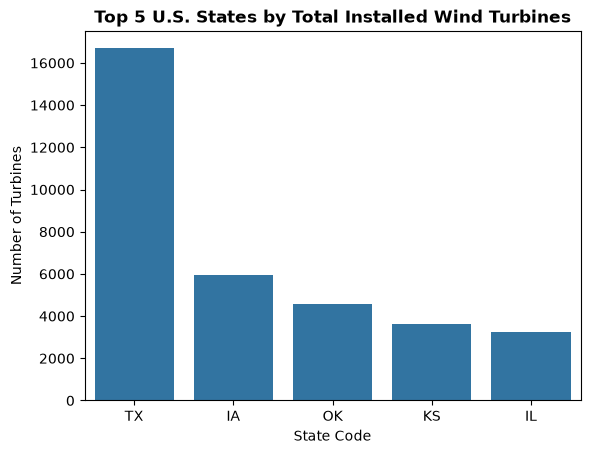

In [40]:
top_states = df_sorted['t_state'].value_counts().head(5)

ax1 = sns.barplot(x=top_states.index, y=top_states.values)
plt.title('Top 5 U.S. States by Total Installed Wind Turbines', fontweight='bold')
plt.xlabel('State Code')
plt.ylabel('Number of Turbines')
plt.show()

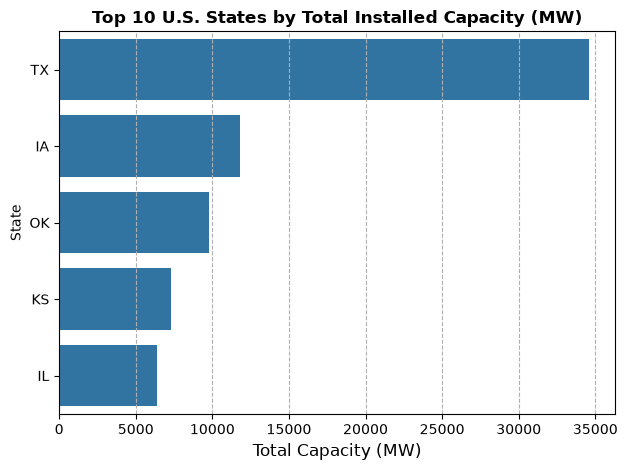

In [41]:
state_capacity = (
    df_filtered.groupby('t_state')['t_cap'].sum() / 1000).sort_values(ascending=False).head(5)
plt.figure()
sns.barplot(x=state_capacity.values, y=state_capacity.index)

plt.title('Top 10 U.S. States by Total Installed Capacity (MW)', fontweight='bold')
plt.xlabel('Total Capacity (MW)', fontsize=12)
plt.ylabel('State')
plt.grid(axis='x', linestyle='--')

plt.tight_layout()
plt.show()

### 4.analyze the growth of turbine capacity over the years

### 5.examine the physical evolution of hub height

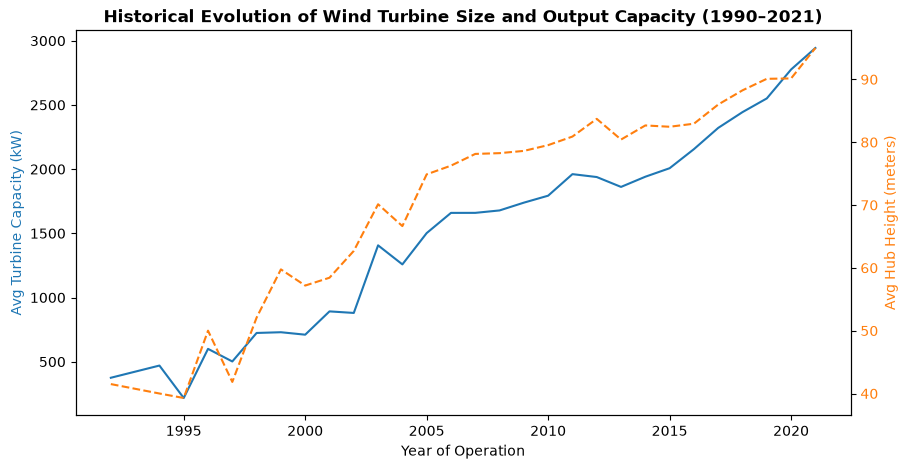

In [42]:
yearly_tech = df_sorted.groupby('p_year')[['t_cap', 't_hh']].mean().reset_index()

fig, ax_cap = plt.subplots(figsize=(10, 5))

ax_cap.set_xlabel('Year of Operation')
ax_cap.set_ylabel('Avg Turbine Capacity (kW)', color='tab:blue')
line1 = ax_cap.plot(yearly_tech['p_year'], yearly_tech['t_cap'])
ax_cap.tick_params(axis='y')
ax_height = ax_cap.twinx()  
ax_height.set_ylabel('Avg Hub Height (meters)', color='tab:orange')
line2 = ax_height.plot(yearly_tech['p_year'], yearly_tech['t_hh'], color='tab:orange',linestyle='--')
ax_height.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Historical Evolution of Wind Turbine Size and Output Capacity (1990–2021)', fontweight='bold')
plt.show()

### 6.compare the market share of GE Wind, Vestas, and other OEMs

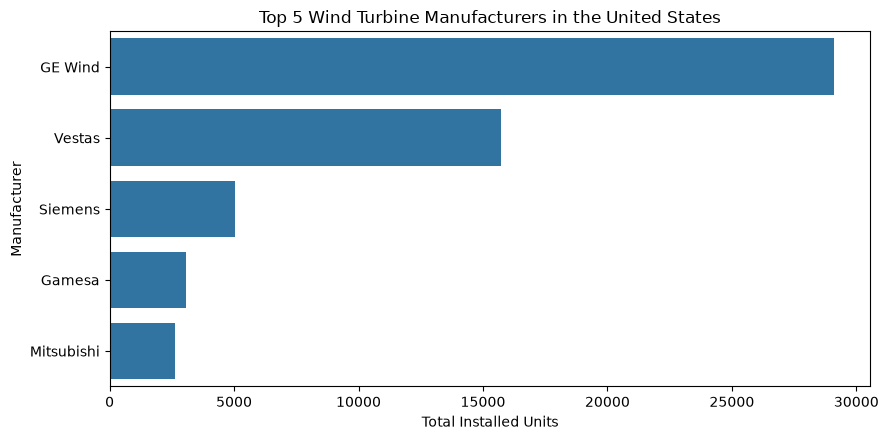

In [43]:
plt.figure(figsize=(9, 4.5))
top_manufacturers = df_sorted['t_manu'].value_counts().head(5)
ax3 = sns.barplot(x=top_manufacturers.values, y=top_manufacturers.index)
plt.title('Top 5 Wind Turbine Manufacturers in the United States')
plt.xlabel('Total Installed Units')
plt.ylabel('Manufacturer')
plt.tight_layout()
plt.show()